# Phase 2 — Calibration Curve Analysis

**Question:** When our Phase 2 model says 70% chance of home win, does it actually happen 70% of the time?

**Model:** XGB×3 + RF×1 ensemble, 97 features (EA + ELO, no DC blend)
**Test set:** 3,313 matches (2023–2024)

Compare with Phase 1: ECE = 0.027, bias: Away +0.009, Draw +0.002, Home -0.012

In [1]:
import numpy as np
import pandas as pd
import joblib, warnings
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('dark_background')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.facecolor'] = '#0A0A0A'
matplotlib.rcParams['axes.facecolor'] = '#111111'
matplotlib.rcParams['axes.edgecolor'] = '#1A1A1A'
matplotlib.rcParams['axes.labelcolor'] = '#A1A1AA'
matplotlib.rcParams['xtick.color'] = '#A1A1AA'
matplotlib.rcParams['ytick.color'] = '#A1A1AA'
matplotlib.rcParams['text.color'] = '#FFFFFF'
matplotlib.rcParams['grid.color'] = '#1A1A1A'
matplotlib.rcParams['grid.linewidth'] = 0.8
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../../data/processed')
MODELS_DIR = Path('../../models')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load Phase 2 model
bundle = joblib.load(MODELS_DIR / 'phase2_model.pkl')
xgb_model = bundle['xgb']
rf_model = bundle['rf']
W_XGB, W_RF = bundle['w_xgb'], bundle['w_rf']
le = bundle['label_encoder']
FEATURE_COLS = bundle['feature_cols']

print(f'Model: XGB×{W_XGB} + RF×{W_RF}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Classes: {le.classes_}  (0=away_win, 1=draw, 2=home_win)')

Model: XGB×3 + RF×1
Features: 97
Classes: ['away_win' 'draw' 'home_win']  (0=away_win, 1=draw, 2=home_win)


In [3]:
# Load test data and join squad features (same pipeline as save_phase2_model.py)
test_df = pd.read_csv(PROCESSED_DIR / 'test_dc.csv')
test_df['date'] = pd.to_datetime(test_df['date'])
test_df['year'] = test_df['date'].dt.year
team_features = pd.read_csv(PROCESSED_DIR / 'team_features_by_year.csv')

SQUAD_FEATURES = [
    'squad_avg_overall', 'squad_median_overall', 'squad_std_overall',
    'squad_top3_avg', 'squad_bottom5_avg',
    'gk_avg', 'def_avg', 'mid_avg', 'fwd_avg',
    'strongest_unit', 'weakest_unit',
    'squad_total_value', 'squad_avg_value',
    'squad_avg_age', 'squad_avg_potential_gap', 'squad_avg_caps',
    'team_pace', 'team_shooting', 'team_passing',
    'team_dribbling', 'team_defending', 'team_physic',
]

def join_and_engineer(df):
    df = df.copy()
    avail = sorted(team_features['year'].unique())
    def get_yr(y):
        c = [x for x in avail if x <= y]
        return max(c) if c else None
    df['fifa_year'] = df['year'].apply(get_yr)
    htf = team_features.rename(columns={f: f'home_{f}' for f in SQUAD_FEATURES})
    htf = htf.rename(columns={'team': 'home_team', 'year': 'fifa_year'})
    atf = team_features.rename(columns={f: f'away_{f}' for f in SQUAD_FEATURES})
    atf = atf.rename(columns={'team': 'away_team', 'year': 'fifa_year'})
    home_cols = ['home_team', 'fifa_year'] + [f'home_{f}' for f in SQUAD_FEATURES]
    away_cols = ['away_team', 'fifa_year'] + [f'away_{f}' for f in SQUAD_FEATURES]
    df = df.merge(htf[home_cols], on=['home_team', 'fifa_year'], how='left')
    df = df.merge(atf[away_cols], on=['away_team', 'fifa_year'], how='left')
    for f in SQUAD_FEATURES:
        df[f'{f}_diff'] = df[f'home_{f}'] - df[f'away_{f}']
    df['overall_ratio'] = df['home_squad_avg_overall'] / df['away_squad_avg_overall'].clip(lower=1)
    df['top3_ratio'] = df['home_squad_top3_avg'] / df['away_squad_top3_avg'].clip(lower=1)
    df['value_ratio_log'] = np.log1p(df['home_squad_total_value']) - np.log1p(df['away_squad_total_value'])
    df['value_ratio'] = (df['home_squad_total_value'] + 1) / (df['away_squad_total_value'] + 1)
    df['home_squad_balance'] = df['home_strongest_unit'] - df['home_weakest_unit']
    df['away_squad_balance'] = df['away_strongest_unit'] - df['away_weakest_unit']
    df['squad_balance_diff'] = df['home_squad_balance'] - df['away_squad_balance']
    df['home_star_gap'] = df['home_squad_top3_avg'] - df['home_squad_avg_overall']
    df['away_star_gap'] = df['away_squad_top3_avg'] - df['away_squad_avg_overall']
    df['star_gap_diff'] = df['home_star_gap'] - df['away_star_gap']
    df['depth_diff'] = df['home_squad_bottom5_avg'] - df['away_squad_bottom5_avg']
    df['squad_std_diff'] = df['home_squad_std_overall'] - df['away_squad_std_overall']
    df['home_attack_vs_def'] = df['home_fwd_avg'] - df['away_def_avg']
    df['away_attack_vs_def'] = df['away_fwd_avg'] - df['home_def_avg']
    df['attack_vs_def_diff'] = df['home_attack_vs_def'] - df['away_attack_vs_def']
    df['mid_battle'] = df['home_mid_avg'] - df['away_mid_avg']
    df['gk_diff'] = df['home_gk_avg'] - df['away_gk_avg']
    df['pace_diff'] = df['home_team_pace'] - df['away_team_pace']
    df['physic_diff'] = df['home_team_physic'] - df['away_team_physic']
    df['shooting_diff'] = df['home_team_shooting'] - df['away_team_shooting']
    df['passing_diff'] = df['home_team_passing'] - df['away_team_passing']
    df['defending_diff'] = df['home_team_defending'] - df['away_team_defending']
    df['dribbling_diff'] = df['home_team_dribbling'] - df['away_team_dribbling']
    df['age_diff'] = df['home_squad_avg_age'] - df['away_squad_avg_age']
    df['caps_diff'] = df['home_squad_avg_caps'] - df['away_squad_avg_caps']
    df['potential_gap_diff'] = df['home_squad_avg_potential_gap'] - df['away_squad_avg_potential_gap']
    df['home_weighted_strength'] = 0.6 * df['home_squad_avg_overall'] + 0.4 * df['home_squad_top3_avg']
    df['away_weighted_strength'] = 0.6 * df['away_squad_avg_overall'] + 0.4 * df['away_squad_top3_avg']
    df['weighted_strength_diff'] = df['home_weighted_strength'] - df['away_weighted_strength']
    return df

test_aug = join_and_engineer(test_df)
y_test = le.transform(test_aug['outcome'].values)
X_test = test_aug[FEATURE_COLS].values

print(f'Test samples: {len(y_test):,}')
print(f'Feature matrix shape: {X_test.shape}')

Test samples: 3,313
Feature matrix shape: (3313, 97)


In [4]:
# Get Phase 2 predictions: XGB×3 + RF×1
xgb_p = xgb_model.predict_proba(X_test)
X_test_rf = np.nan_to_num(X_test, 0)
rf_p = rf_model.predict_proba(X_test_rf)
y_pred_proba = (W_XGB * xgb_p + W_RF * rf_p) / (W_XGB + W_RF)

print(f'Overall log loss: {log_loss(y_test, y_pred_proba):.4f}')
print(f'Mean predicted: away={y_pred_proba[:,0].mean():.3f}  draw={y_pred_proba[:,1].mean():.3f}  home={y_pred_proba[:,2].mean():.3f}')

Overall log loss: 0.8258
Mean predicted: away=0.261  draw=0.222  home=0.517


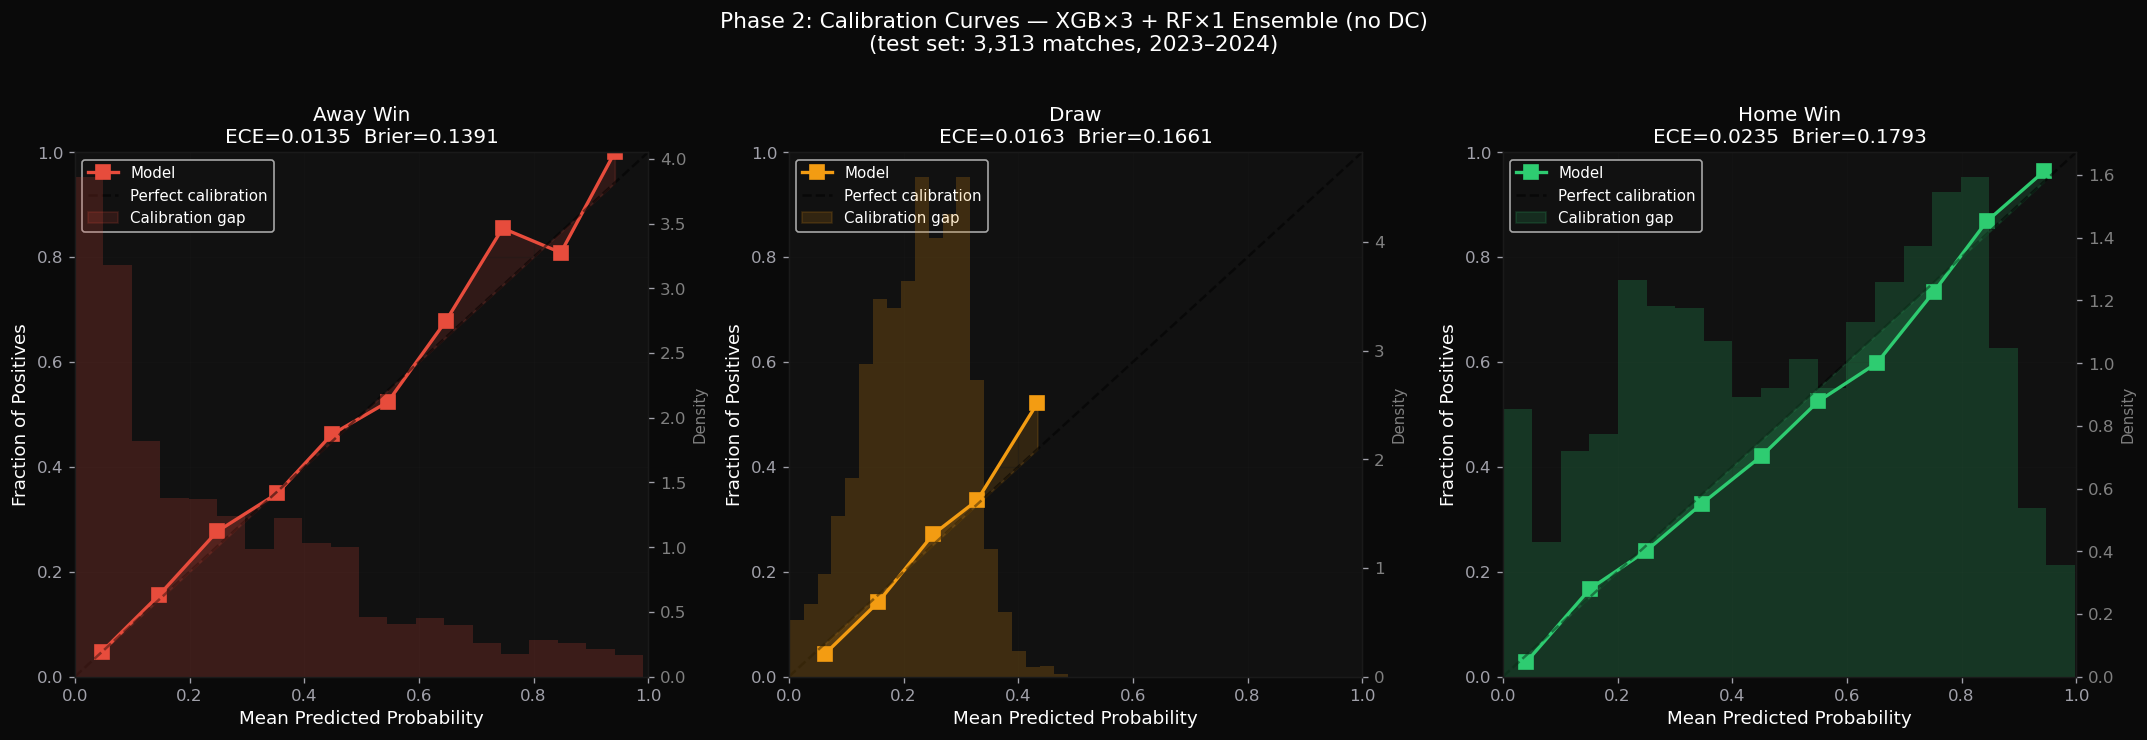


ECE scores: Away=0.0135  Draw=0.0163  Home=0.0235
Mean ECE: 0.0178


In [5]:
# Calibration curves for all 3 classes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

class_names = ['Away Win', 'Draw', 'Home Win']
colors = ['#e74c3c', '#f39c12', '#2ecc71']
ece_scores = []

for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
    ax = axes[cls_idx]
    y_binary = (y_test == cls_idx).astype(int)
    probs = y_pred_proba[:, cls_idx]

    # Calibration curve - 10 bins
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_binary, probs, n_bins=10, strategy='uniform'
    )

    ax.plot(mean_predicted_value, fraction_of_positives,
            's-', color=color, linewidth=2, markersize=8, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.fill_between(mean_predicted_value,
                    fraction_of_positives, mean_predicted_value,
                    alpha=0.15, color=color, label='Calibration gap')

    # ECE calculation
    bin_edges = np.linspace(0, 1, 11)
    ece = 0
    for i in range(10):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_acc = y_binary[mask].mean()
            bin_conf = probs[mask].mean()
            ece += mask.sum() / len(probs) * abs(bin_acc - bin_conf)
    ece_scores.append(ece)

    brier = brier_score_loss(y_binary, probs)

    ax.set_xlabel('Mean Predicted Probability', fontsize=11)
    ax.set_ylabel('Fraction of Positives', fontsize=11)
    ax.set_title(f'{cls_name}\nECE={ece:.4f}  Brier={brier:.4f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.hist(probs, bins=20, alpha=0.2, color=color, density=True)
    ax2.set_ylabel('Density', fontsize=9, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

plt.suptitle('Phase 2: Calibration Curves — XGB×3 + RF×1 Ensemble (no DC)\n(test set: 3,313 matches, 2023–2024)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../images/phase2_05_calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nECE scores: Away={ece_scores[0]:.4f}  Draw={ece_scores[1]:.4f}  Home={ece_scores[2]:.4f}')
print(f'Mean ECE: {np.mean(ece_scores):.4f}')

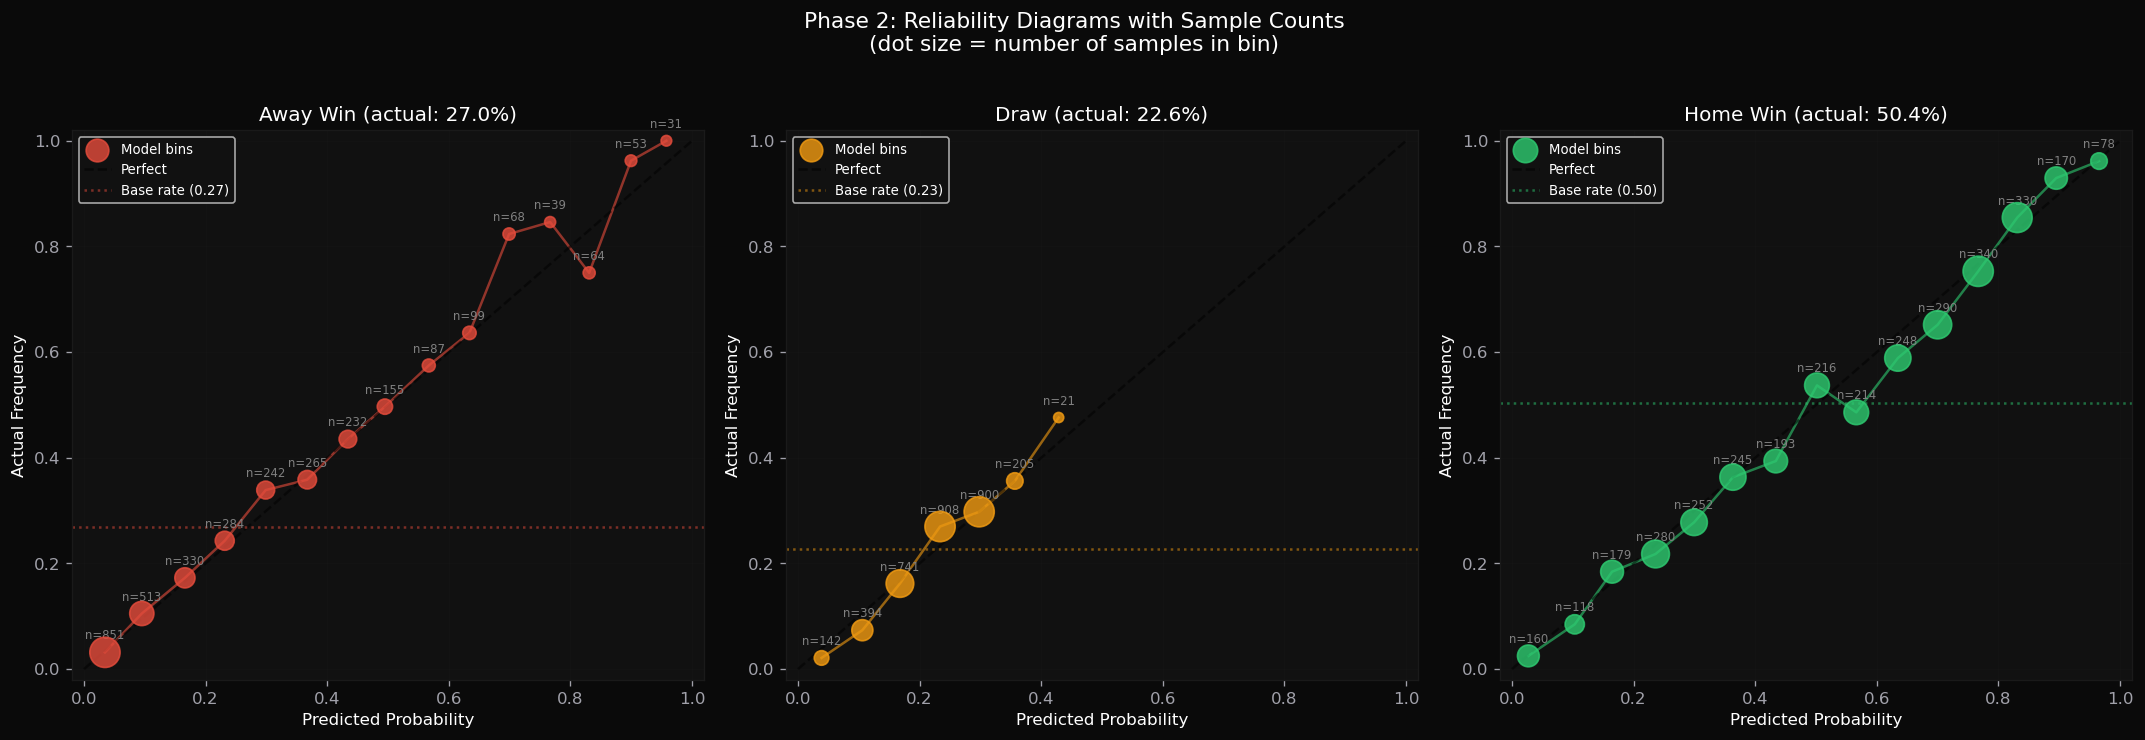

In [6]:
# Reliability diagram with confidence intervals + per-bin sample counts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
    ax = axes[cls_idx]
    y_binary = (y_test == cls_idx).astype(int)
    probs = y_pred_proba[:, cls_idx]

    bin_edges = np.linspace(0, 1, 16)
    bin_centers, bin_acc, bin_n = [], [], []

    for i in range(15):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i + 1])
        if mask.sum() >= 5:
            bin_centers.append(probs[mask].mean())
            bin_acc.append(y_binary[mask].mean())
            bin_n.append(mask.sum())

    bin_centers = np.array(bin_centers)
    bin_acc = np.array(bin_acc)
    bin_n = np.array(bin_n)

    sizes = (bin_n / bin_n.max()) * 300 + 30
    ax.scatter(bin_centers, bin_acc, s=sizes, c=color, alpha=0.8, zorder=5, label='Model bins')
    ax.plot(bin_centers, bin_acc, '-', color=color, alpha=0.6, linewidth=1.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')

    for x, y, n in zip(bin_centers, bin_acc, bin_n):
        ax.annotate(f'n={n}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color='gray')

    base_rate = y_binary.mean()
    ax.axhline(base_rate, color=color, linestyle=':', alpha=0.5,
               label=f'Base rate ({base_rate:.2f})')

    actual_pct = y_binary.mean() * 100
    ax.set_title(f'{cls_name} (actual: {actual_pct:.1f}%)', fontsize=12)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Actual Frequency')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)

plt.suptitle('Phase 2: Reliability Diagrams with Sample Counts\n(dot size = number of samples in bin)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../images/phase2_05_reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Summary scorecard — Phase 2 vs Phase 1
print('=' * 60)
print('PHASE 2 CALIBRATION SCORECARD')
print('=' * 60)
print(f'Model: XGB×{W_XGB} + RF×{W_RF} (no DC)')
print(f'Test set: {len(y_test):,} matches')
print(f'Log Loss: {log_loss(y_test, y_pred_proba):.4f}')
print()

print('Class distribution:')
for i, name in enumerate(le.classes_):
    actual_rate = (y_test == i).mean()
    avg_pred = y_pred_proba[:, i].mean()
    brier = brier_score_loss((y_test == i).astype(int), y_pred_proba[:, i])
    print(f'  {name:10s}: actual={actual_rate:.3f}  avg_pred={avg_pred:.3f}  '
          f'bias={avg_pred - actual_rate:+.3f}  brier={brier:.4f}')

print()
print(f'Mean ECE: {np.mean(ece_scores):.4f}')
print()
print('Phase 1 comparison:')
print('  Phase 1: ECE=0.0273  bias: Away +0.009, Draw +0.002, Home -0.012')
print(f'  Phase 2: ECE={np.mean(ece_scores):.4f}  bias: Away {y_pred_proba[:,0].mean() - (y_test==0).mean():+.3f}, '
      f'Draw {y_pred_proba[:,1].mean() - (y_test==1).mean():+.3f}, '
      f'Home {y_pred_proba[:,2].mean() - (y_test==2).mean():+.3f}')
print('=' * 60)

PHASE 2 CALIBRATION SCORECARD
Model: XGB×3 + RF×1 (no DC)
Test set: 3,313 matches
Log Loss: 0.8258

Class distribution:
  away_win  : actual=0.270  avg_pred=0.261  bias=-0.009  brier=0.1391
  draw      : actual=0.226  avg_pred=0.222  bias=-0.005  brier=0.1661
  home_win  : actual=0.504  avg_pred=0.517  bias=+0.013  brier=0.1793

Mean ECE: 0.0178

Phase 1 comparison:
  Phase 1: ECE=0.0273  bias: Away +0.009, Draw +0.002, Home -0.012
  Phase 2: ECE=0.0178  bias: Away -0.009, Draw -0.005, Home +0.013
